# Object weight histogram

Histogram of object weights, with the object names for each bin written above the bar, and the mean +/- 1 std overlaid.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [8]:
data = {
    "Soap dispenser": 787,
    "Coffee pot": 728,
    "Vase": 962,
    "Cube (red)": 957,
    "Candle": 987,
    "Plant": 367,
    "Ring": 921,
    "Biscoff": 621,
    "Coffee": 403,
    "Tomato sauce": 624,
    "Glass cup": 427,
    "Duct tape": 398,
    "Book": 1857,
    "Bag of beans": 502,
    "Bag of quinoa": 508,
    "Cylinder (1000g)": 1000,
    "Cylinder (500g)": 500,
    "Cylinder (200g)": 200,
    "Cylinder (100g)": 100,
}

df = pd.DataFrame(sorted(data.items(), key=lambda kv: kv[1]), columns=["object", "weight_g"])
df

,object,weight_g
0,Cylinder (100g),100
1,Cylinder (200g),200
2,Plant,367
3,Duct tape,398
4,Coffee,403
5,Glass cup,427
6,Cylinder (500g),500
7,Bag of beans,502
8,Bag of quinoa,508
9,Biscoff,621


In [9]:
mean = df["weight_g"].mean()
std = df["weight_g"].std()
print(f"mean = {mean:.1f} g, std = {std:.1f} g")

mean = 676.3 g, std = 394.1 g


In [10]:
import re

BIN_WIDTH = 150
bins = np.arange(0, df["weight_g"].max() + BIN_WIDTH, BIN_WIDTH)

counts, bin_edges = np.histogram(df["weight_g"], bins=bins)

# object name + weight for each bin, for the on-bar labels
bin_labels = []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (df["weight_g"] >= lo) & (df["weight_g"] < hi)
    rows = df.loc[mask]
    names = rows["object"].str.replace(r"\s*\(\d+g\)$", "", regex=True)  # avoid "(1000g) (1000g)"
    bin_labels.append("\n".join(f"{name} ({w:.0f}g)" for name, w in zip(names, rows["weight_g"])))

max_lines_per_bin = max((label.count("\n") + 1 for label in bin_labels if label), default=1)

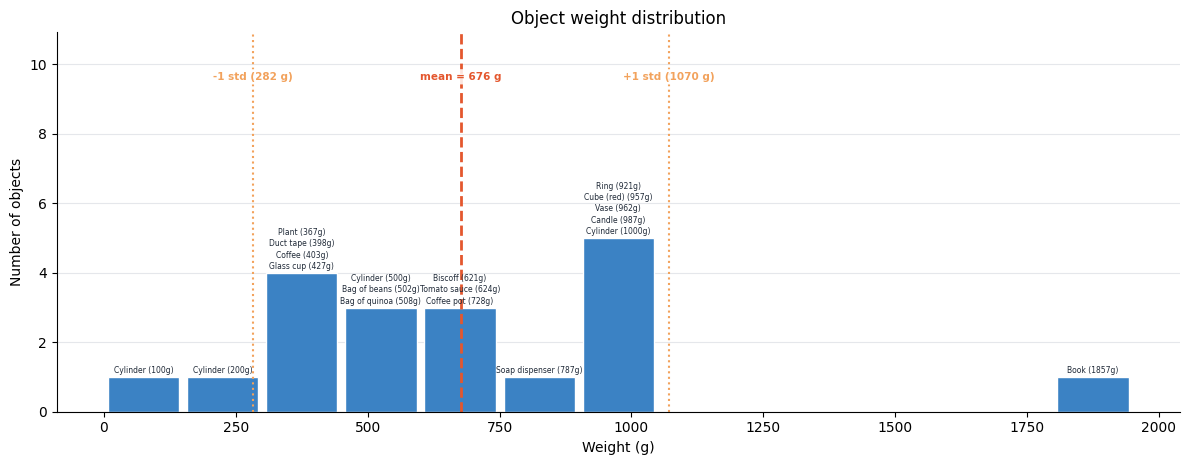

In [12]:
BLUE = "#3B82C4"  # single sequential hue for a magnitude histogram
ACCENT = "#E4572E"  # warm accent for mean/std, distinct from the bars
ACCENT_SOFT = "#F2A25C"  # lighter accent for the +/-1 std lines

fig, ax = plt.subplots(figsize=(12, 3 + 0.35 * max_lines_per_bin))

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.bar(bin_centers, counts, width=BIN_WIDTH * 0.9, color=BLUE, edgecolor="white", linewidth=1)

# write the object name + weight on top of each bar
for x, count, label in zip(bin_centers, counts, bin_labels):
    if count == 0:
        continue
    ax.text(
        x, count + 0.05, label,
        ha="center", va="bottom", fontsize=5.5, color="#1f2937", linespacing=1.35,
    )

# mean and std
ax.axvline(mean, color=ACCENT, linestyle="--", linewidth=2)
ax.axvline(mean - std, color=ACCENT_SOFT, linestyle=":", linewidth=1.5)
ax.axvline(mean + std, color=ACCENT_SOFT, linestyle=":", linewidth=1.5)

ymax = counts.max() + 0.7 * max_lines_per_bin + 1
label_kwargs = dict(ha="center", va="bottom", fontsize=7.5, fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.85))
ax.text(mean, ymax, f"mean = {mean:.0f} g", color=ACCENT, **label_kwargs)
ax.text(mean - std, ymax, f"-1 std ({mean - std:.0f} g)", color=ACCENT_SOFT, **label_kwargs)
ax.text(mean + std, ymax, f"+1 std ({mean + std:.0f} g)", color=ACCENT_SOFT, **label_kwargs)

ax.set_ylim(0, ymax * 1.15)
ax.set_xlabel("Weight (g)")
ax.set_ylabel("Number of objects")
ax.set_title("Object weight distribution")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e7eb", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()